### Import Packages

In [117]:
import pandas as pd
import numpy as np
import cvxpy as cp
import os
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn import linear_model
import statsmodels.api as sm
from scipy.optimize import minimize
from functools import *

# Supress scientific notation
np.set_printoptions(suppress=True)

### Import Dataset and Merge on Date

In [118]:
filelist = [c for c in os.listdir() if 'csv' in c]

df_list = []
for f in filelist:
    print(f)
    
    df = pd.read_csv(f)
    if 'Adj Close' in df.columns:
        df.rename(columns = {'Adj Close':f.split('.')[0]},inplace = True)
        df['Date'] = df['Date'].apply(lambda x:x.replace('-',''))
        df= df[['Date',f.split('.')[0]]].copy()
        df = df.set_index('Date')
        df_list.append(df)

    elif 'Adjusted Close' in  df.columns:
        df.rename(columns = {'Adjusted Close':f.split('.')[0]},inplace = True)
        df['Date'] = df['Date'].apply(lambda x:''.join((x.split('-'))[::-1]))
        df= df[['Date',f.split('.')[0]]].copy()
        df = df.set_index('Date')
        df_list.append(df)

# Load Fama-French 3-Factor Data
ff_3f = pd.read_csv('ff3.csv', parse_dates=['Date'])
ff_3f = ff_3f.set_index('Date')
ff_3f['Date'] = ff_3f.index = ff_3f.index.strftime('%Y%m%d')

CG.csv
BAC.csv
ff3.csv
CME.csv
MS-PF.csv
JPM.csv
BRK-A.csv
BLK.csv


### Calculate Return

In [119]:
df_data = pd.concat(df_list,axis=1)
df_data = df_data.dropna()
df_data.reset_index()
df_return = df_data/df_data.shift(1)

In [120]:
df_return = df_return.loc['20131210':]

### Risk/Variance of Stock

In [121]:
Sigma = np.cov(np.stack(df_return.loc['20131210':].values.T))
display(Sigma)

array([[0.00045773, 0.00020845, 0.00012335, 0.00005546, 0.00019116,
        0.00012203, 0.00020488],
       [0.00020845, 0.00035023, 0.00015733, 0.00004276, 0.00027129,
        0.00015501, 0.00023199],
       [0.00012335, 0.00015733, 0.00023706, 0.00004329, 0.00014904,
        0.00010616, 0.0001453 ],
       [0.00005546, 0.00004276, 0.00004329, 0.0000539 , 0.00004681,
        0.00003191, 0.00004329],
       [0.00019116, 0.00027129, 0.00014904, 0.00004681, 0.00025924,
        0.00014247, 0.00020383],
       [0.00012203, 0.00015501, 0.00010616, 0.00003191, 0.00014247,
        0.00013274, 0.00014338],
       [0.00020488, 0.00023199, 0.0001453 , 0.00004329, 0.00020383,
        0.00014338, 0.00027743]])

In [122]:
# Check: Ensure positive definite
np.linalg.eigvals(Sigma)

array([0.00118937, 0.00025203, 0.00013496, 0.0000823 , 0.00004624,
       0.00003826, 0.00002518])

### Perform Convex Optimization

In [123]:
# Define weight variable
weight = cp.Variable(len(df_data.columns))

In [124]:
# Maximize Utility Function = E[r] − 0.5 * A * sigma^2
# where A is the risk aversion parameter

A = 3; 
obj = cp.Maximize(df_return.loc['20131210':].mean().values @ weight - 0.5*A*cp.quad_form(weight, Sigma))

In [125]:
# prob = cp.Problem(obj, [ cp.sum(weight) == 1, weight >=0 , weight <= 0.35])
prob = cp.Problem(obj, [ cp.sum(weight) == 1, weight >=0 ])
prob.solve(solver=cp.ECOS) # Solve with ECOS_BB
optimal_weights = weight.value

In [126]:
print("Solver status:", prob.status)
print("Optimal value:", prob.value)
print("Weights (Percentage):", optimal_weights * 100)

Solver status: optimal
Optimal value: 1.0004004540967701
Weights (Percentage): [ 0.00001296  0.00001993 86.63871033 13.36109529  0.00008898  0.000035
  0.0000375 ]


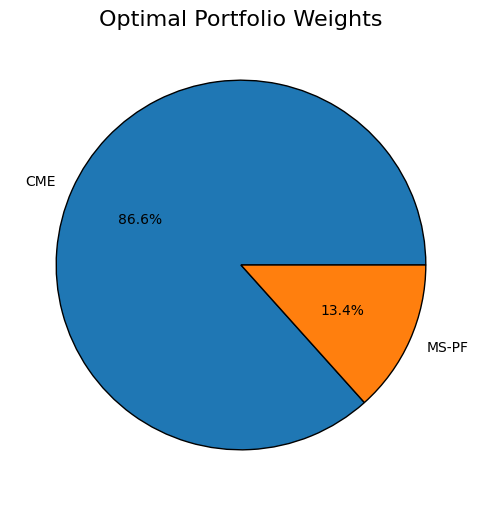

In [127]:
plt.figure(figsize=(6, 6))

# Remove weights that are effectively zero
optimal_weights[optimal_weights < 0.0001] = 0
nonzero_weights = optimal_weights[optimal_weights > 0]

# Create the pie chart
plt.pie(
    nonzero_weights, 
    labels=df_data.columns[optimal_weights > 0],  # Show labels for nonzero weights
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '', 
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)

plt.title('Optimal Portfolio Weights', fontsize=16)
plt.show()


In [128]:
# Calculate Portfolio Return and Risk
portfolio_return = np.sum(df_return.loc['20131210':].mean() * optimal_weights)
portfolio_risk = np.sqrt(np.dot(optimal_weights.T, np.dot(Sigma, optimal_weights)))

print(f"Portfolio Return: {portfolio_return:.2f}")
print(f"Portfolio Risk: {portfolio_risk:.2f}")

Portfolio Return: 1.00
Portfolio Risk: 0.01


### Regression: Testing the FF3 model

In [129]:
# Calculate daily portfolio returns
portfolio_returns_daily = df_return.dot(optimal_weights)
portfolio_returns_daily = pd.DataFrame(portfolio_returns_daily, columns=['Portfolio_Return'], index=df_return.index)

# Merge with Fama-French data (both have Date as datetime index)
data_for_regression = portfolio_returns_daily.merge(ff_3f, left_index=True, right_index=True, how='inner').dropna()

# Calculate daily portfolio excess returns
data_for_regression['Portfolio_Excess_Return'] = data_for_regression['Portfolio_Return'] - data_for_regression['RF']

# Define dependent and independent variables
y = data_for_regression['Portfolio_Excess_Return']
X = data_for_regression[['Mkt-RF', 'SMB', 'HML']] 
X = sm.add_constant(X)

# Run the regression
model1 = sm.OLS(y, X).fit()
print(model1.summary())

                               OLS Regression Results                              
Dep. Variable:     Portfolio_Excess_Return   R-squared:                       0.386
Model:                                 OLS   Adj. R-squared:                  0.385
Method:                      Least Squares   F-statistic:                     331.8
Date:                     Fri, 21 Mar 2025   Prob (F-statistic):          3.89e-167
Time:                             16:24:29   Log-Likelihood:                 4892.3
No. Observations:                     1588   AIC:                            -9777.
Df Residuals:                         1584   BIC:                            -9755.
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

### Test the CAPM model

In [130]:
# Calculate daily portfolio returns
portfolio_returns_daily = df_return.dot(optimal_weights)
portfolio_returns_daily = pd.DataFrame(portfolio_returns_daily, columns=['Portfolio_Return'], index=df_return.index)

# Merge with Fama-French data (both have Date as datetime index)
data_for_regression = portfolio_returns_daily.merge(ff_3f, left_index=True, right_index=True, how='inner').dropna()

# Calculate daily portfolio excess returns
data_for_regression['Portfolio_Excess_Return'] = data_for_regression['Portfolio_Return'] - data_for_regression['RF']

# Define dependent and independent variables
y = data_for_regression['Portfolio_Excess_Return']
X = data_for_regression[['Mkt-RF']] 
X = sm.add_constant(X)

# Run the regression
model2 = sm.OLS(y, X).fit()
print(model2.summary())

                               OLS Regression Results                              
Dep. Variable:     Portfolio_Excess_Return   R-squared:                       0.367
Model:                                 OLS   Adj. R-squared:                  0.366
Method:                      Least Squares   F-statistic:                     918.2
Date:                     Fri, 21 Mar 2025   Prob (F-statistic):          1.66e-159
Time:                             16:24:29   Log-Likelihood:                 4867.8
No. Observations:                     1588   AIC:                            -9732.
Df Residuals:                         1586   BIC:                            -9721.
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

### Visualizations

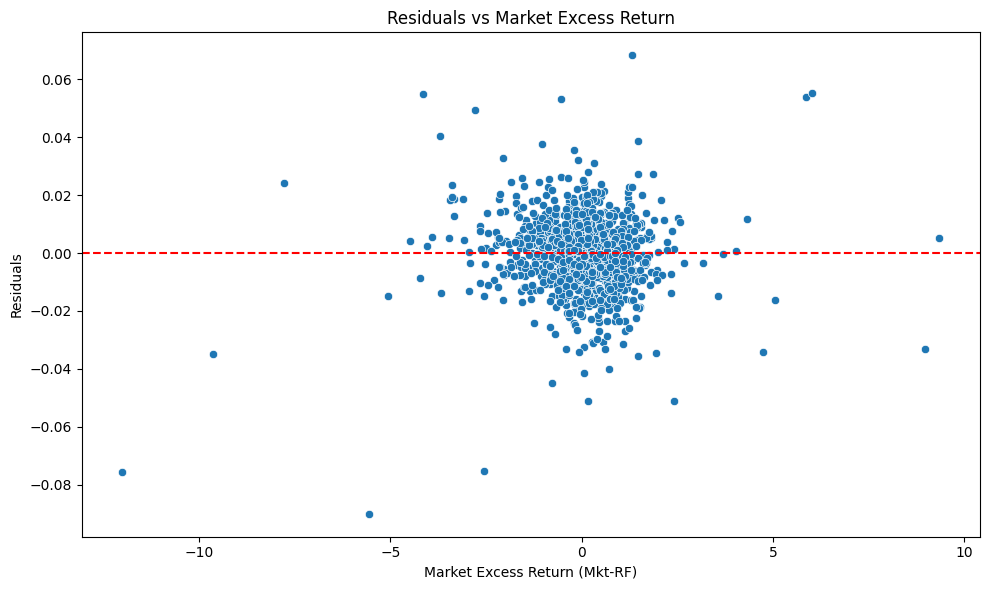

In [131]:
# 1. Residual Plot of the Regression
residuals = model1.resid
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data_for_regression['Mkt-RF'], y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Market Excess Return')
plt.xlabel('Market Excess Return (Mkt-RF)')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

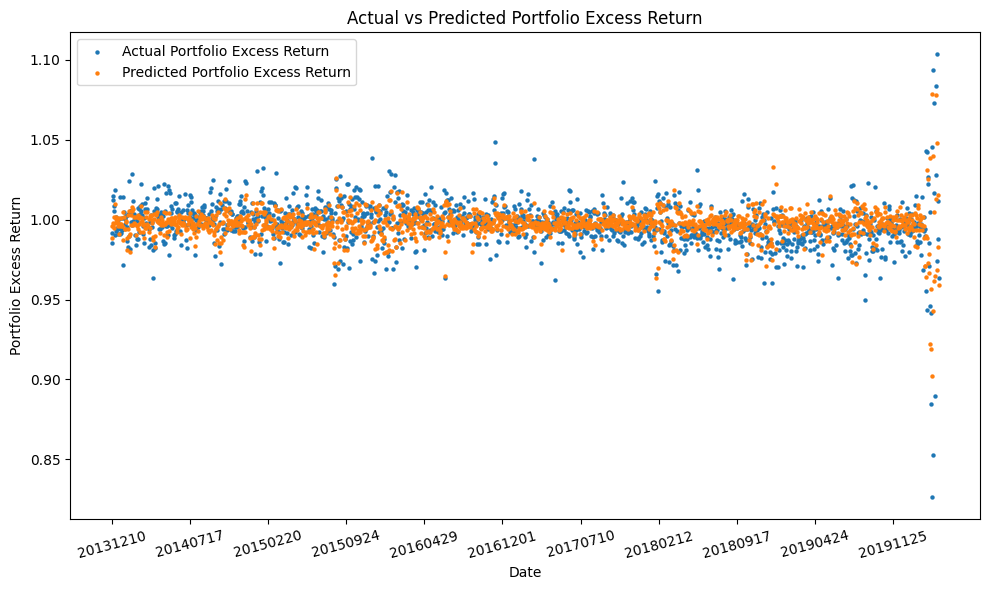

In [132]:
# 2. Plot of Actual vs Predicted Portfolio Excess Return
predicted_values = model1.fittedvalues
plt.figure(figsize=(10, 6))
plt.scatter(data_for_regression.index, data_for_regression['Portfolio_Excess_Return'], label='Actual Portfolio Excess Return', s=10, linewidths= 0.01)
plt.scatter(data_for_regression.index, predicted_values, label='Predicted Portfolio Excess Return', s=10, linewidths= 0.01)

plt.title('Actual vs Predicted Portfolio Excess Return')
plt.xlabel('Date')
plt.ylabel('Portfolio Excess Return')

plt.legend()
plt.xticks(data_for_regression.index[::150], rotation=15)
plt.tight_layout()
plt.show()

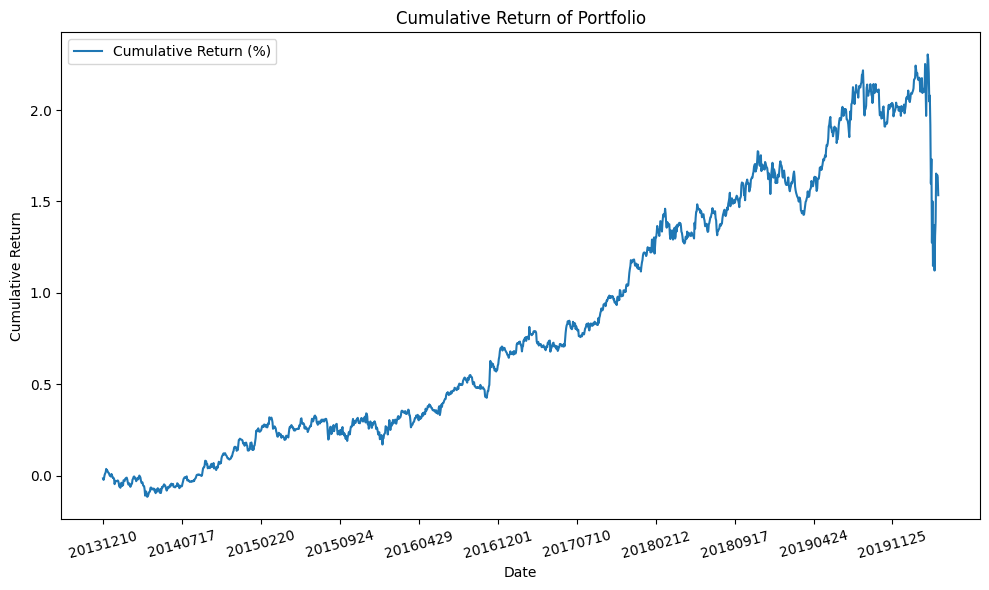

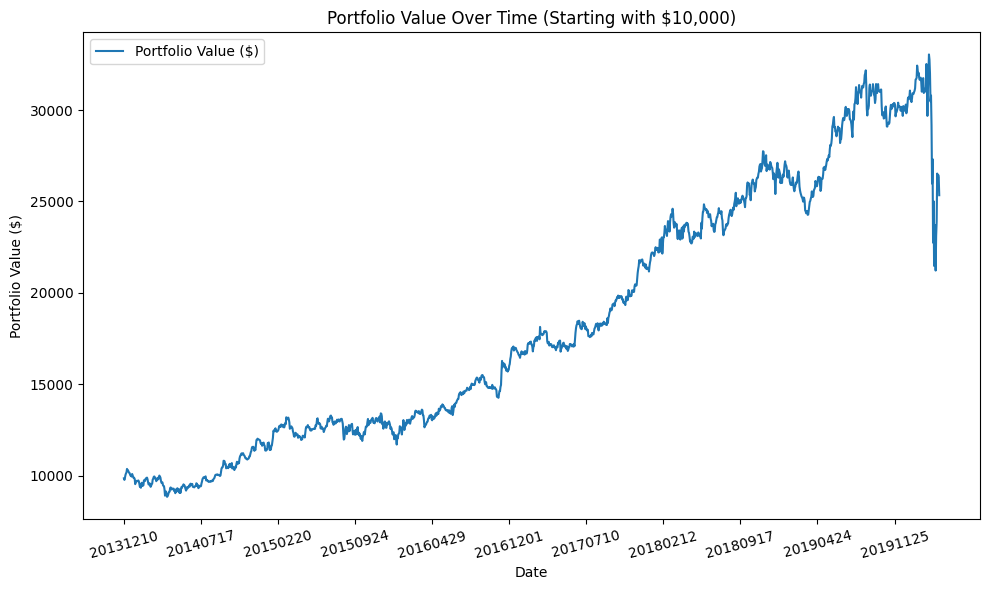

In [133]:
# 3. Plot of Cumulative Return and Portfolio Value

# Calculate cumulative return (as a multiplier)
cumulative_return_multiplier = portfolio_returns_daily['Portfolio_Return'].cumprod()

# If you prefer to see the cumulative return as a percentage gain/loss:
cumulative_return_percentage = cumulative_return_multiplier - 1

# Compute portfolio value starting from $10,000
initial_investment = 10000
portfolio_value = initial_investment * cumulative_return_multiplier

# Plot cumulative return percentage over time
plt.figure(figsize=(10, 6))
plt.plot(cumulative_return_percentage.index, cumulative_return_percentage, label='Cumulative Return (%)')
plt.title('Cumulative Return of Portfolio')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.xticks(data_for_regression.index[::150], rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

# Plot portfolio value over time
plt.figure(figsize=(10, 6))
plt.plot(portfolio_value.index, portfolio_value, label='Portfolio Value ($)')
plt.title('Portfolio Value Over Time (Starting with $10,000)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.xticks(data_for_regression.index[::150], rotation=15)
plt.legend()
plt.tight_layout()
plt.show()


In [134]:
#4. Fancy Interactive Plot (Just for fun)

import plotly.graph_objects as go

# Create data for a candlestick chart
portfolio_returns_daily['High'] = portfolio_returns_daily['Portfolio_Return'] + portfolio_returns_daily['Portfolio_Return'].std()
portfolio_returns_daily['Low'] = portfolio_returns_daily['Portfolio_Return'] - portfolio_returns_daily['Portfolio_Return'].std()
portfolio_returns_daily['Open'] = portfolio_returns_daily['Portfolio_Return']
portfolio_returns_daily['Close'] = portfolio_returns_daily['Portfolio_Return']

# Create a Candlestick chart using Plotly
fig = go.Figure(data=[go.Candlestick(
                x=portfolio_returns_daily.index,
                open=portfolio_returns_daily['Open'],
                high=portfolio_returns_daily['High'],
                low=portfolio_returns_daily['Low'],
                close=portfolio_returns_daily['Close'],
                increasing_line_color='green',
                decreasing_line_color='red'
)])

fig.update_layout(
    title='Portfolio Daily Candlestick Chart',
    xaxis_title='Date',
    yaxis_title='Portfolio Returns',
    template="plotly_dark"
)
fig.show()

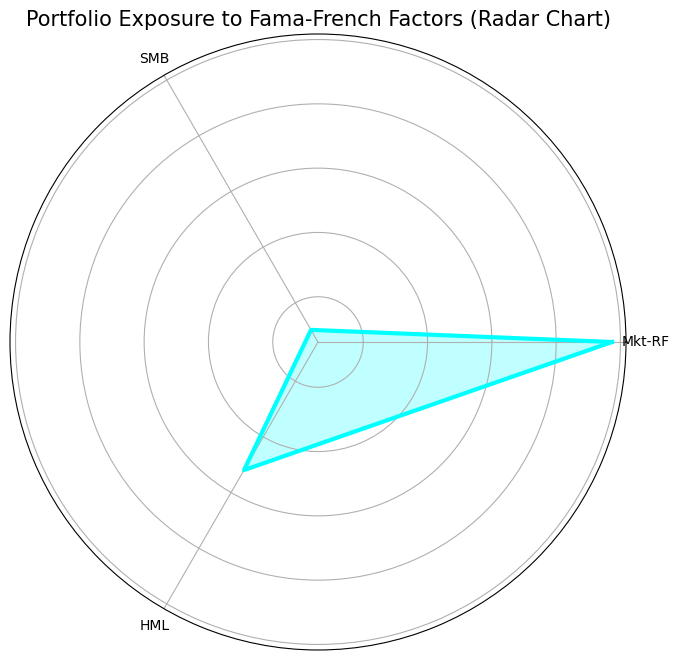

In [135]:
#5. Radar Chart of Portfolio Exposure to Fama-French Factors

labels = ['Mkt-RF', 'SMB', 'HML']
values = [model1.params['Mkt-RF'], model1.params['SMB'], model1.params['HML']]

# Create a radar chart
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
values += values[:1]  # To close the loop
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
ax.fill(angles, values, color='cyan', alpha=0.25)
ax.plot(angles, values, color='cyan', linewidth=3)

ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title('Portfolio Exposure to Fama-French Factors (Radar Chart)', size=15)
plt.show()